# Hierarchical Clustering - Annual Income and Spending Score

This notebook applies **Hierarchical Clustering** as an **unsupervised learning** method using **Annual Income** and **Spending Score**.

## Step 1: Import Libraries & Load Data
This step imports the required libraries and loads the dataset for clustering analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set(style='whitegrid')

df = pd.read_csv('data/Shopping_Mall_Customer_Segmentation_Data_.csv')
df_clean = df.dropna().drop_duplicates().copy()

print('Dataset shape:', df.shape)
print('Cleaned dataset shape:', df_clean.shape)
display(df_clean.head())

Dataset shape: (15079, 5)
Cleaned dataset shape: (15079, 5)


,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76


## Step 2: Data Preparation for Unsupervised Learning
This step selects the features required for hierarchical clustering and standardizes them so that both variables contribute fairly to the clustering process.

In [2]:
# Detect the spending score column name safely
possible_spending_cols = ['Spending Score', 'Spending Score (1-100)', 'SpendingScore']
spending_col = next((col for col in possible_spending_cols if col in df_clean.columns), None)

if spending_col is None:
    raise KeyError("Spending Score column not found. Please check the dataset column name.")

features = ['Annual Income', spending_col]
X = df_clean[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Selected features:', features)
display(X.head())

Selected features: ['Annual Income', 'Spending Score']


,Annual Income,Spending Score
0,151479,89
1,185088,95
2,70912,76
3,55460,57
4,153752,76


## Step 3: Train Final Model
In this step, the final Hierarchical Clustering model is trained using Agglomerative Clustering with 5 clusters.

In [3]:

hc_model = AgglomerativeClustering(n_clusters=5, linkage='ward')
cluster_labels = hc_model.fit_predict(X_scaled)

n_clusters = len(set(cluster_labels))

df_result = df_clean.copy()
df_result['Cluster'] = cluster_labels

print('Unique clusters:', sorted(df_result['Cluster'].unique()))
print('Number of clusters:', n_clusters)
display(df_result.head())

Unique clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Number of clusters: 5


,Customer ID,Age,Gender,Annual Income,Spending Score,Cluster
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89,3
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95,3
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76,1
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57,1
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76,3


## Step 4: Evaluate the Model
The model is evaluated using the **Silhouette Score**, which is suitable for unsupervised learning because it measures how well the clusters are separated.

Since this is an **unsupervised learning** task, no target label such as **Gender** is used for training. Gender, if available, can be reviewed later only for cluster interpretation.

In [4]:

import pandas as pd
import pickle

# Metrics for selected final model
sil_score = silhouette_score(X_scaled, cluster_labels)
db_score = davies_bouldin_score(X_scaled, cluster_labels)

print('=' * 72)
print('           HIERARCHICAL CLUSTERING EVALUATION METRICS')
print('=' * 72)
print(f'  Algorithm                 : Hierarchical Clustering')
print(f'  Linkage Method            : Ward')
print(f'  Input Feature Space       : X_scaled')
print(f'  Number of Clusters        : {n_clusters}')
print(f'  Silhouette Score          : {sil_score:.4f}  (higher = better)')
print(f'  Davies-Bouldin Index      : {db_score:.4f}  (lower = better)')
print(f'  Noise Points              : 0')
print('=' * 72)

print('\n📌 User-facing explanation:')
print('   1. Hierarchical Clustering groups customers based on similarity.')
print('   2. Ward linkage is used to minimize within-cluster variance.')
print('   3. Silhouette Score evaluates how well-separated the clusters are.')
print('   4. Davies-Bouldin Index measures cluster compactness and separation.')
print('   5. Hierarchical Clustering does not produce noise points; all data points are assigned to clusters.')

scores = {
    'algorithm': 'HierarchicalClustering',
    'linkage': 'ward',
    'n_clusters': int(n_clusters),
    'silhouette': round(float(sil_score), 4),
    'davies_bouldin': round(float(db_score), 4),
    'noise': 0
}

pickle.dump(scores, open('data/hierarchical_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('data/hierarchical_labels.pkl', 'wb'))

print('\n✅ Scores saved.')

           HIERARCHICAL CLUSTERING EVALUATION METRICS
  Algorithm                 : Hierarchical Clustering
  Linkage Method            : Ward
  Input Feature Space       : X_scaled
  Number of Clusters        : 5
  Silhouette Score          : 0.3308  (higher = better)
  Davies-Bouldin Index      : 1.0023  (lower = better)
  Noise Points              : 0

📌 User-facing explanation:
   1. Hierarchical Clustering groups customers based on similarity.
   2. Ward linkage is used to minimize within-cluster variance.
   3. Silhouette Score evaluates how well-separated the clusters are.
   4. Davies-Bouldin Index measures cluster compactness and separation.
   5. Hierarchical Clustering does not produce noise points; all data points are assigned to clusters.

✅ Scores saved.


## Cluster Visualisation
This section visualizes the hierarchical clustering results using a 2D scatter plot and a dendrogram.

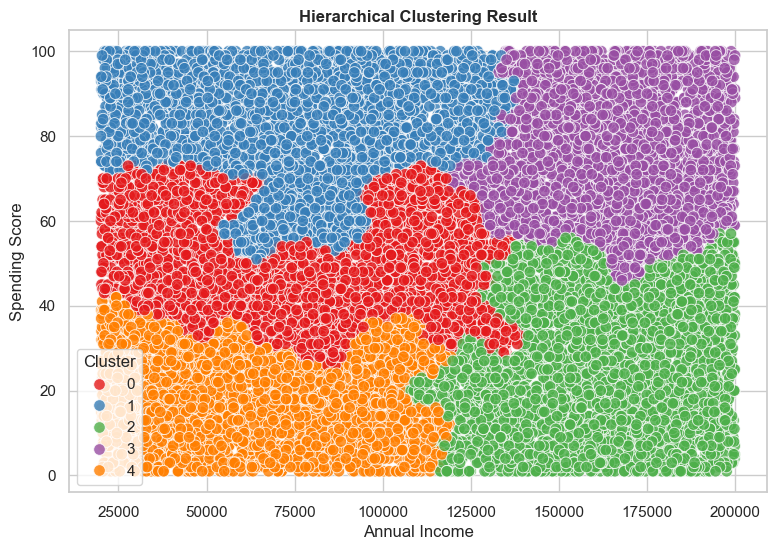

In [5]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_result,
    x='Annual Income',
    y=spending_col,
    hue='Cluster',
    palette='Set1',
    s=70,
    alpha=0.8
)
plt.title('Hierarchical Clustering Result', fontweight='bold')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()

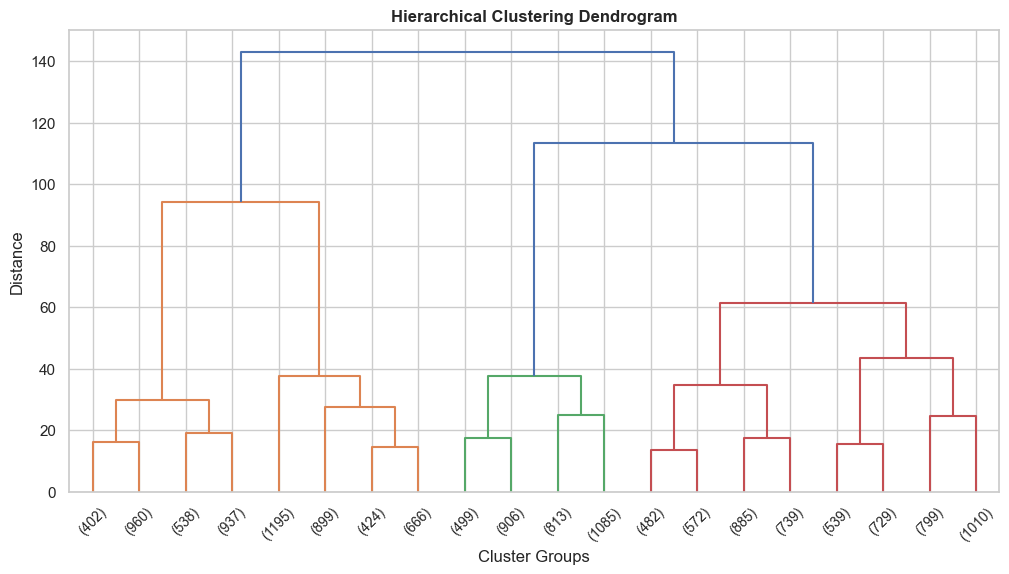

In [6]:
plt.figure(figsize=(12, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram', fontweight='bold')
plt.xlabel('Cluster Groups')
plt.ylabel('Distance')
plt.show()

## Cluster Profile Analysis
This section summarizes the average values of the selected features in each cluster to support interpretation of customer segments.

If **Gender** is available in the dataset, it is used only for post-cluster profiling, not as an input feature.

In [7]:
cluster_profile = df_result.groupby('Cluster')[['Annual Income', spending_col]].mean().round(2)
cluster_profile['Count'] = df_result.groupby('Cluster').size()

display(cluster_profile)

if 'Gender' in df_result.columns:
    gender_profile = pd.crosstab(df_result['Cluster'], df_result['Gender'], normalize='index').round(2)
    print('Gender Distribution by Cluster:')
    display(gender_profile)

,Annual Income,Spending Score,Count
Cluster,,,
0,76846.45,50.13,3077
1,76022.85,82.48,3184
2,161355.90,25.40,3303
3,164985.86,75.66,2837
4,65450.41,17.73,2678


Gender Distribution by Cluster:


Gender,Female,Male
Cluster,,
0,0.50,0.50
1,0.49,0.51
2,0.50,0.50
3,0.50,0.50
4,0.49,0.51


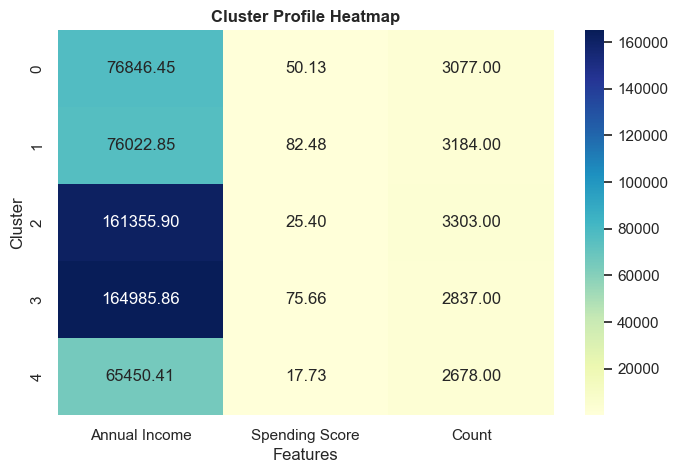

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(cluster_profile, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Cluster Profile Heatmap', fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Cluster')
plt.show()

## Save Model & Predict New Customer
Agglomerative Clustering does not support direct prediction for new data like KMeans. Therefore, this section saves the preprocessing objects and demonstrates how a new customer can be transformed and compared for analysis purposes.

In [9]:
joblib.dump(scaler, 'data/hierarchical_scaler.pkl')

print('Scaler saved successfully.')

Scaler saved successfully.


In [10]:
new_customer = pd.DataFrame([{
    'Annual Income': X['Annual Income'].mean(),
    spending_col: X[spending_col].mean()
}])

new_customer_scaled = scaler.transform(new_customer)

print('New Customer:')
display(new_customer)

print('Scaled New Customer:')
print(new_customer_scaled)

print('Note: AgglomerativeClustering does not provide a built-in predict() function for unseen customers.')

New Customer:


,Annual Income,Spending Score
0,109742.880562,50.591617


Scaled New Customer:
[[0. 0.]]
Note: AgglomerativeClustering does not provide a built-in predict() function for unseen customers.
